In [1]:
# Task 05 - Neural Style Transfer

import torch

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU not available. Please enable T4 GPU.")

PyTorch version: 2.11.0+cu128
GPU available: Tesla T4


In [2]:
# Install required libraries

!pip install -q torch torchvision pillow matplotlib numpy

print("Required libraries installed successfully!")

Required libraries installed successfully!


In [3]:
# Import libraries

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Step 7: Check uploaded images

import os

print("Files in Colab:")

for file in os.listdir("/content"):
    print(file)

Files in Colab:
.config
famous painting.jpg
normal image.jpg
sample_data


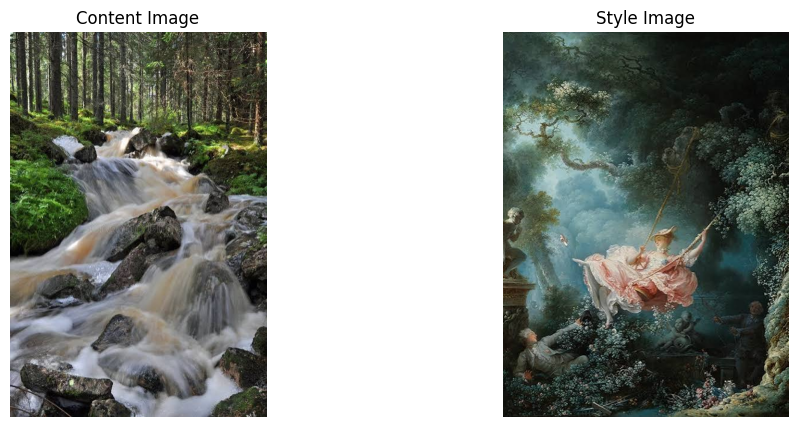

Content image size: (451, 678)
Style image size: (476, 643)


In [8]:
# Step 8: Load and display content and style images

content_path = "/content/normal image.jpg"
style_path = "/content/famous painting.jpg"

content_image = Image.open(content_path).convert("RGB")
style_image = Image.open(style_path).convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Image")
plt.axis("off")

plt.show()

print("Content image size:", content_image.size)
print("Style image size:", style_image.size)

In [9]:
# Step 9: Load the pretrained VGG19 model

import torchvision.models as models

# Load pretrained VGG19
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device)

# We don't need to train VGG19
for parameter in vgg.parameters():
    parameter.requires_grad = False

print("Pretrained VGG19 loaded successfully!")
print("Model is running on:", device)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 142MB/s]


Pretrained VGG19 loaded successfully!
Model is running on: cuda


In [10]:
# Step 10: Preprocess content and style images

image_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform images
content_tensor = transform(content_image).unsqueeze(0).to(device)
style_tensor = transform(style_image).unsqueeze(0).to(device)

print("Images preprocessed successfully!")
print("Content tensor shape:", content_tensor.shape)
print("Style tensor shape:", style_tensor.shape)

Images preprocessed successfully!
Content tensor shape: torch.Size([1, 3, 256, 256])
Style tensor shape: torch.Size([1, 3, 256, 256])


In [11]:
# Step 11: Define VGG19 feature layers

# Content layer
content_layer = "21"

# Style layers
style_layers = [
    "0",
    "5",
    "10",
    "19",
    "28"
]

print("Content layer:", content_layer)
print("Style layers:", style_layers)
print("VGG19 feature layers defined successfully!")

Content layer: 21
Style layers: ['0', '5', '10', '19', '28']
VGG19 feature layers defined successfully!


In [12]:
# Step 12: Extract content and style features

def get_features(image):
    features = {}
    x = image

    for name, layer in vgg._modules.items():
        x = layer(x)

        if name == content_layer:
            features["content"] = x

        if name in style_layers:
            features[f"style_{name}"] = x

    return features


# Extract features
content_features = get_features(content_tensor)
style_features = get_features(style_tensor)

print("Feature extraction completed successfully!")

print("\nContent feature shape:")
print(content_features["content"].shape)

print("\nStyle feature shapes:")
for key, value in style_features.items():
    print(key, ":", value.shape)

Feature extraction completed successfully!

Content feature shape:
torch.Size([1, 512, 32, 32])

Style feature shapes:
style_0 : torch.Size([1, 64, 256, 256])
style_5 : torch.Size([1, 128, 128, 128])
style_10 : torch.Size([1, 256, 64, 64])
style_19 : torch.Size([1, 512, 32, 32])
content : torch.Size([1, 512, 32, 32])
style_28 : torch.Size([1, 512, 16, 16])


In [13]:
# Step 13: Define Gram Matrix and Style Loss

def gram_matrix(tensor):
    batch, channels, height, width = tensor.size()

    features = tensor.view(batch, channels, height * width)

    gram = torch.bmm(features, features.transpose(1, 2))

    return gram / (channels * height * width)


def calculate_style_loss(generated_features, style_features):
    style_loss = 0

    for layer in style_layers:
        generated_gram = gram_matrix(
            generated_features[f"style_{layer}"]
        )

        style_gram = gram_matrix(
            style_features[f"style_{layer}"]
        )

        style_loss += torch.mean(
            (generated_gram - style_gram) ** 2
        )

    return style_loss


print("Gram Matrix function created successfully!")
print("Style loss function created successfully!")

Gram Matrix function created successfully!
Style loss function created successfully!


In [14]:
# Step 14: Define Content Loss and Total Loss

def calculate_content_loss(generated_features, content_features):
    return torch.mean(
        (generated_features["content"] -
         content_features["content"]) ** 2
    )


# Weight for style and content
style_weight = 1e6
content_weight = 1

print("Content loss function created successfully!")
print("Style weight:", style_weight)
print("Content weight:", content_weight)

Content loss function created successfully!
Style weight: 1000000.0
Content weight: 1


In [15]:
# Step 15: Create the initial generated image

generated_image = content_tensor.clone().detach()
generated_image.requires_grad_(True)

print("Initial generated image created successfully!")
print("Generated image shape:", generated_image.shape)

Initial generated image created successfully!
Generated image shape: torch.Size([1, 3, 256, 256])


In [16]:
# Step 16: Set optimization parameters

optimizer = optim.Adam(
    [generated_image],
    lr=0.02
)

num_steps = 300

print("Optimizer created successfully!")
print("Learning rate:", 0.02)
print("Optimization steps:", num_steps)

Optimizer created successfully!
Learning rate: 0.02
Optimization steps: 300


In [17]:
# Step 17: Perform Neural Style Transfer

print("Starting Neural Style Transfer...")
print("Please wait while the image is optimized...\n")

for step in range(num_steps):

    optimizer.zero_grad()

    # Extract features from generated image
    generated_features = get_features(generated_image)

    # Calculate content loss
    content_loss = calculate_content_loss(
        generated_features,
        content_features
    )

    # Calculate style loss
    style_loss = calculate_style_loss(
        generated_features,
        style_features
    )

    # Calculate total loss
    total_loss = (
        content_weight * content_loss
        + style_weight * style_loss
    )

    # Backpropagation
    total_loss.backward()

    # Update generated image
    optimizer.step()

    # Keep pixel values within a reasonable range
    with torch.no_grad():
        generated_image.clamp_(-2, 2)

    # Display progress
    if (step + 1) % 50 == 0:
        print(
            f"Step [{step + 1}/{num_steps}] | "
            f"Content Loss: {content_loss.item():.4f} | "
            f"Style Loss: {style_loss.item():.4f} | "
            f"Total Loss: {total_loss.item():.4f}"
        )

print("\n✅ Neural Style Transfer completed successfully!")

Starting Neural Style Transfer...
Please wait while the image is optimized...

Step [50/300] | Content Loss: 2.0946 | Style Loss: 0.0000 | Total Loss: 5.2568
Step [100/300] | Content Loss: 1.9053 | Style Loss: 0.0000 | Total Loss: 4.4082
Step [150/300] | Content Loss: 1.8443 | Style Loss: 0.0000 | Total Loss: 4.1046
Step [200/300] | Content Loss: 1.8080 | Style Loss: 0.0000 | Total Loss: 3.9347
Step [250/300] | Content Loss: 1.7799 | Style Loss: 0.0000 | Total Loss: 3.8223
Step [300/300] | Content Loss: 1.7624 | Style Loss: 0.0000 | Total Loss: 3.7381

✅ Neural Style Transfer completed successfully!


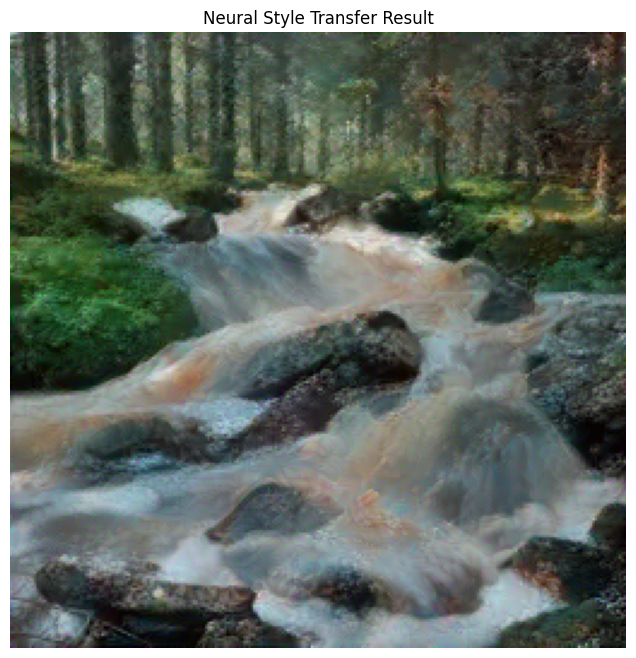

Final stylized image displayed successfully!


In [18]:
# Step 18: Display the final stylized image

def denormalize(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = image * torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)
    image = image + torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    return torch.clamp(image, 0, 1)


final_image = denormalize(generated_image)

plt.figure(figsize=(8, 8))
plt.imshow(final_image.permute(1, 2, 0).numpy())
plt.title("Neural Style Transfer Result")
plt.axis("off")
plt.show()

print("Final stylized image displayed successfully!")

In [19]:
# Step 19: Save the final stylized image

output_dir = "/content/task5_results"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "neural_style_transfer_result.png"
)

# Convert tensor to image
final_image_pil = Image.fromarray(
    (final_image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
)

final_image_pil.save(output_path)

print("Final stylized image saved successfully!")
print("File:", output_path)

Final stylized image saved successfully!
File: /content/task5_results/neural_style_transfer_result.png


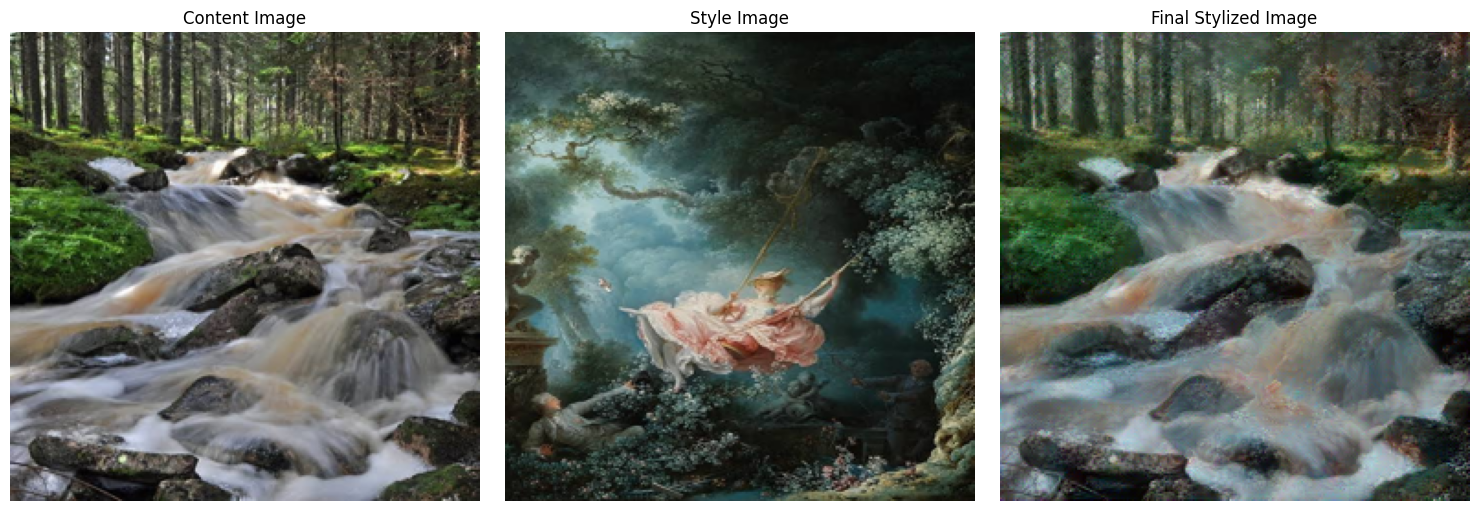

Comparison image saved successfully!
File: /content/task5_results/style_transfer_comparison.png


In [20]:
# Step 20: Create a comparison of Content, Style and Result

content_display = np.array(content_image.resize((256, 256)))
style_display = np.array(style_image.resize((256, 256)))
result_display = np.array(final_image_pil)

comparison_path = os.path.join(
    output_dir,
    "style_transfer_comparison.png"
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(content_display)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(style_display)
plt.title("Style Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_display)
plt.title("Final Stylized Image")
plt.axis("off")

plt.tight_layout()
plt.savefig(comparison_path, bbox_inches="tight")
plt.show()

print("Comparison image saved successfully!")
print("File:", comparison_path)